In [1]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.path.join(os.getcwd(), "plots")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Oscillations and stable up and down

In [2]:
aln = ALNModel()
N = aln.params.N
aln.params.dt = .1

aln.params.mufe_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.mufi_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.seem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.seiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.rates_exc_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.rates_inh_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.IA_init = 0.0 * np.random.uniform(0, 1, (N, 1))  # pA

aln.params.sigma_ou = 0.
aln.params.mue_ou = np.array( [0.] )
aln.params.mui_ou = np.array( [0.] )

state_vars = aln.state_vars
init_vars = aln.init_vars

def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]
                    
def set_params_slow():
    # external currents for aE limit cycle (slow)
    aln.params.ext_exc_current = 4.
    aln.params.ext_inh_current = 2.
    
def set_params_fast():
    # external currents for EI limit cycle (fast)
    aln.params.ext_exc_current = 2.5
    aln.params.ext_inh_current = 0.
    
def set_params_up():
    # external currents for up state
    aln.params.ext_exc_current = 5.
    aln.params.ext_inh_current = 1.
    
def set_params_down():
    # external currents for up state
    aln.params.ext_exc_current = 2.
    aln.params.ext_inh_current = 3.

In [3]:
aln.params.duration = 800.
aln.params.mue_ext_mean = 0.0
aln.params.mui_ext_mean = 0.0

control0 = aln.getZeroControl()

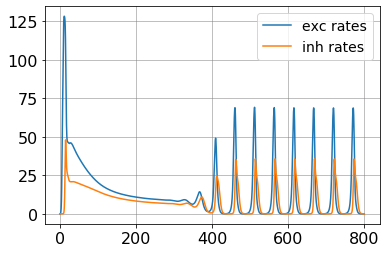

In [4]:
set_params_fast()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

fast_osc_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        fast_osc_init[i] = aln.state[state_vars[i]][0]
    else:
        fast_osc_init[i] = aln.state[state_vars[i]][0,-1]

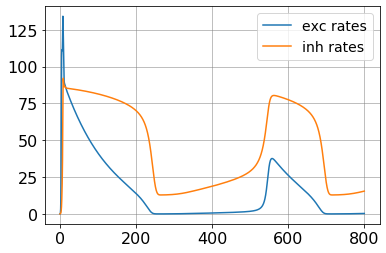

In [5]:
set_params_slow()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

slow_osc_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        slow_osc_init[i] = aln.state[state_vars[i]][0]
    else:
        slow_osc_init[i] = aln.state[state_vars[i]][0,-1]

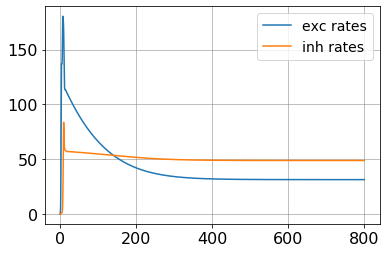

[31.3076 48.768 ]


In [6]:
set_params_up()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

up_rates = np.zeros((2))
up_rates[0] = aln.rates_exc[0,-1]
up_rates[1] = aln.rates_inh[0,-1]

print(up_rates)

up_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        up_init[i] = aln.state[state_vars[i]][0]
    else:
        up_init[i] = aln.state[state_vars[i]][0,-1]

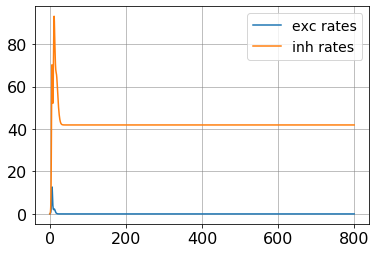

[4.4580e-10 4.1918e+01]


In [7]:
set_params_down()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

down_rates = np.zeros((2))
down_rates[0] = aln.rates_exc[0,-1]
down_rates[1] = aln.rates_inh[0,-1]

print(down_rates)

down_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        down_init[i] = aln.state[state_vars[i]][0]
    else:
        down_init[i] = aln.state[state_vars[i]][0,-1]

In [8]:
def setmaxmincontrol(cntrl_vars):
    max_cntrl = np.zeros(( 4 ))
    min_cntrl = np.zeros(( 4 ))
    if cntrl_vars == [0]:
        max_cntrl[0] = 5.
        min_cntrl[0] = - 5.
    elif cntrl_vars == [1]:
        max_cntrl[1] = 5.
        min_cntrl[1] = - 5.
    elif cntrl_vars == [2]:
        max_cntrl[2] = 0.15
        min_cntrl[2] = 0.
    elif cntrl_vars == [0,1]:
        max_cntrl[0] = 5.
        min_cntrl[0] = - 5.
        max_cntrl[1] = 5.
        min_cntrl[1] = - 5.
    elif cntrl_vars == [0,2]:
        max_cntrl[0] = 5.
        min_cntrl[0] = - 5.
        max_cntrl[2] = 0.15
        min_cntrl[2] = 0.
    elif cntrl_vars == [1,2]:
        max_cntrl[1] = 5.
        min_cntrl[1] = - 5.
        max_cntrl[2] = 0.15
        min_cntrl[2] = 0.
    elif cntrl_vars == [0,1,2]:
        max_cntrl[0] = 5.
        min_cntrl[0] = - 5.
        max_cntrl[1] = 5.
        min_cntrl[1] = - 5.
        max_cntrl[2] = 0.15
        min_cntrl[2] = 0.
            
    return max_cntrl, min_cntrl      

def findclosestindex(osc_rate, stable_rate, startind):
    mindiff = 1000.
    minind = -1
    for t in range(startind, len(osc_rate)):
        diff = np.abs(osc_rate[t] - stable_rate)
        if diff < mindiff:
            mindiff = diff
            minind = t
    return mindiff, minind
        
    
def findclosestindex_2d(osc_rate, stable_rate, startind):
    mindiff = 1000.
    minind = -1
    for t in range(startind, len(osc_rate[0,:])):
        diff = np.abs(osc_rate[0,t] - stable_rate[0]) + np.abs(osc_rate[1,t] - stable_rate[1])
        if diff < mindiff:
            mindiff = diff
            minind = t
    return mindiff, minind

def setpredur(prec_vars):
    if prec_vars == [0]:
        dur_pre = dur_pre_e
    elif prec_vars == [1]:
        dur_pre = dur_pre_i
    else:
        dur_pre = dur_pre_2d
    n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
    
    return dur_pre, n_pre

In [9]:
c_var = [ [0], [1], [2], [0], [1], [2],
         [0,1], [0,1], [0,2], [0,2], [1,2], [1,2],
         [0,1,2], [0,1,2],
         [0], [1], [2], [0,1], [0,2], [1,2], [0,1,2] ]
p_var = [ [0], [1], [0], [1], [0], [1],
         [0], [1], [0], [1], [0], [1],
         [0], [1],
         [0,1], [0,1], [0,1], [0,1], [0,1], [0,1], [0,1] ]

max_it = 50
set_params_slow()
initVars = slow_osc_init

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

sheet = "C_b_"

target_rates = np.array( [down_rates[0], down_rates[1]])

# 40 timesteps max delay
n_dt_maxDelay = aln.getMaxDelay()


In [10]:
dur = 600

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()

aln.run(control=control0)
mindiff_e, minind_e = findclosestindex(aln.rates_exc[0,:], target_rates[0], 250)
print(mindiff_e, minind_e)
dur_pre_e = ( minind_e - n_dt_maxDelay ) / 10.
print(dur_pre_e)

mindiff_i, minind_i = findclosestindex(aln.rates_inh[0,:], target_rates[1], 250)
print(mindiff_i, minind_i)
dur_pre_i = ( minind_i - n_dt_maxDelay ) / 10.
print(dur_pre_i)

findclosestindex_2d
mindiff_2d, minind_2d = findclosestindex_2d(np.array( [aln.rates_exc[0,:], aln.rates_inh[0,:]] ),
                                            target_rates, 250)
print(mindiff_2d, minind_2d)
dur_pre_2d = ( minind_2d - n_dt_maxDelay ) / 10.
print(dur_pre_2d)

0.014378359876793041 3625
358.5
0.03370360624479929 1811
177.1
1.4240927093938514 3409
336.9


In [11]:
def settarget(initVars_, dur_, dur_pre_, n_pre_):
    aln.params.duration = dur_

    # set low state rates as target
    target = aln.getZeroTarget()
    target[:,0,n_dt_maxDelay:] = target_rates[0]
    target[:,1,n_dt_maxDelay:] = target_rates[1]

    aln.params.duration = dur_ + dur_pre_
    setinit(initVars_)
    aln.run(control=aln.getZeroControl())
    target[:,0,:n_dt_maxDelay] = aln.rates_exc[0,n_pre_:n_pre_+n_dt_maxDelay]
    target[:,1,:n_dt_maxDelay] = aln.rates_inh[0,n_pre_:n_pre_+n_dt_maxDelay]
    
    aln.params.duration = dur_

    #print(aln.rates_exc[0,n_pre_:n_pre_+n_dt_maxDelay])
    
    return target

    #plt.plot(np.arange(0,dur+0.1,0.1), target[0,0,:])

## 0

set cost params
control input:  [0] , precision measure:  [0]
RUN  0 , total integrated cost =  1.8485013314754908e-05
RUN  1 , total integrated cost =  1.6947655673938038e-05
RUN  2 , total integrated cost =  1.6947549134209844e-05
RUN  3 , total integrated cost =  1.69475462194584e-05
RUN  4 , total integrated cost =  1.6947546215146178e-05
RUN  5 , total integrated cost =  1.6947546215145934e-05
RUN  6 , total integrated cost =  1.69475462151458e-05
RUN  7 , total integrated cost =  1.694754621514569e-05


ERROR:root:Problem in initial value trasfer


RUN  8 , total integrated cost =  1.694754621514569e-05
Control only changes marginally.
RUN  8 , total integrated cost =  1.694754621514569e-05
Improved over  8  iterations by  8.317370798873043  percent.
Problem in initial value trasfer:  Vmean_exc -66.44625475776829 -66.4609634346849


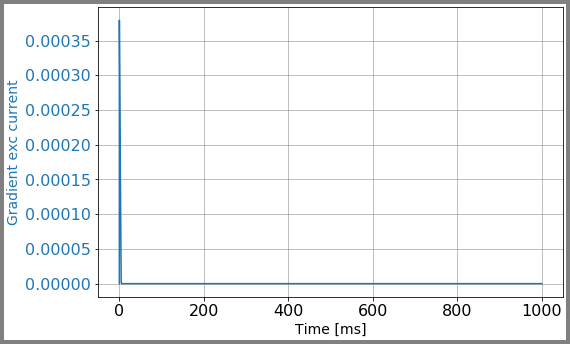

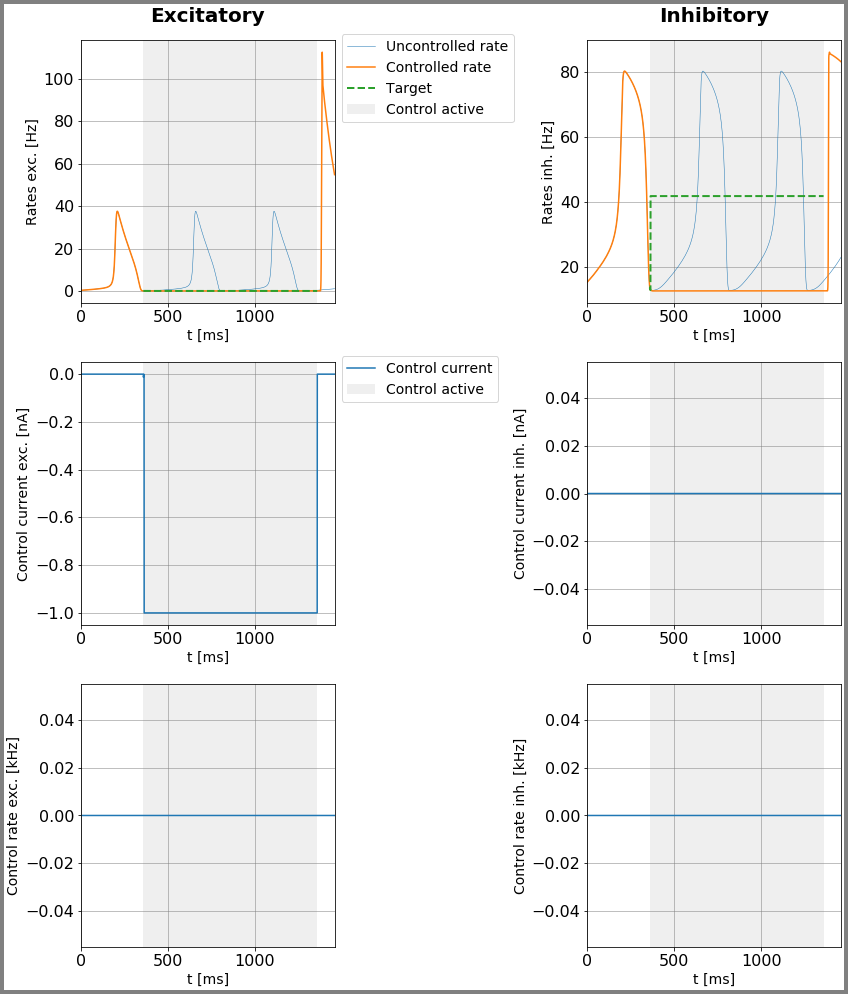

In [12]:
# C.0.a)

dur = 1000
dur_post = 100
n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

case_ind = 0
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

dur_pre, n_pre = setpredur(prec_vars)

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

target = settarget(initVars, dur, dur_pre, n_pre)

setinit(initVars)
control0 = aln.getZeroControl()

#control1 = bestControla[:,:,n_pre-1:-n_post+1]
control0[0,0,n_dt_maxDelay:] = -5.

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.)

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

set cost params
RUN  0 , total integrated cost =  374010.9157976897
RUN  1 , total integrated cost =  581.1793406253266
RUN  2 , total integrated cost =  549.7779109380656
RUN  3 , total integrated cost =  548.114566247804
RUN  4 , total integrated cost =  545.4221019316443
RUN  5 , total integrated cost =  540.689403820051
RUN  6 , total integrated cost =  534.4115276425005
RUN  7 , total integrated cost =  521.7849976000997
RUN  8 , total integrated cost =  513.7956988494211
RUN  9 , total integrated cost =  503.17635551284474
RUN  10 , total integrated cost =  492.32904379538996
RUN  11 , total integrated cost =  479.6458689852075
RUN  12 , total integrated cost =  472.59420666108275
RUN  13 , total integrated cost =  471.2004089807621
RUN  14 , total integrated cost =  471.1988707294889
RUN  15 , total integrated cost =  471.1988707294885
RUN  16 , total integrated cost =  471.19887072948484
RUN  17 , total integrated cost =  471.1988707294848


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  18 , total integrated cost =  471.1988707294848
Control only changes marginally.
RUN  18 , total integrated cost =  471.1988707294848
Improved over  18  iterations by  99.87401467421759  percent.
Problem in initial value trasfer:  Vmean_exc -66.44625475776829 -66.4609634346849
Problem in initial value trasfer:  Vmean_exc -59.99613814904524 -59.989313524136534


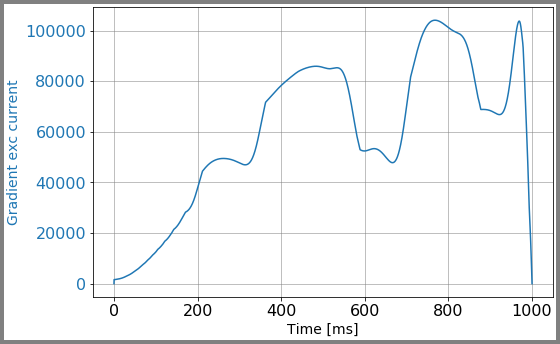

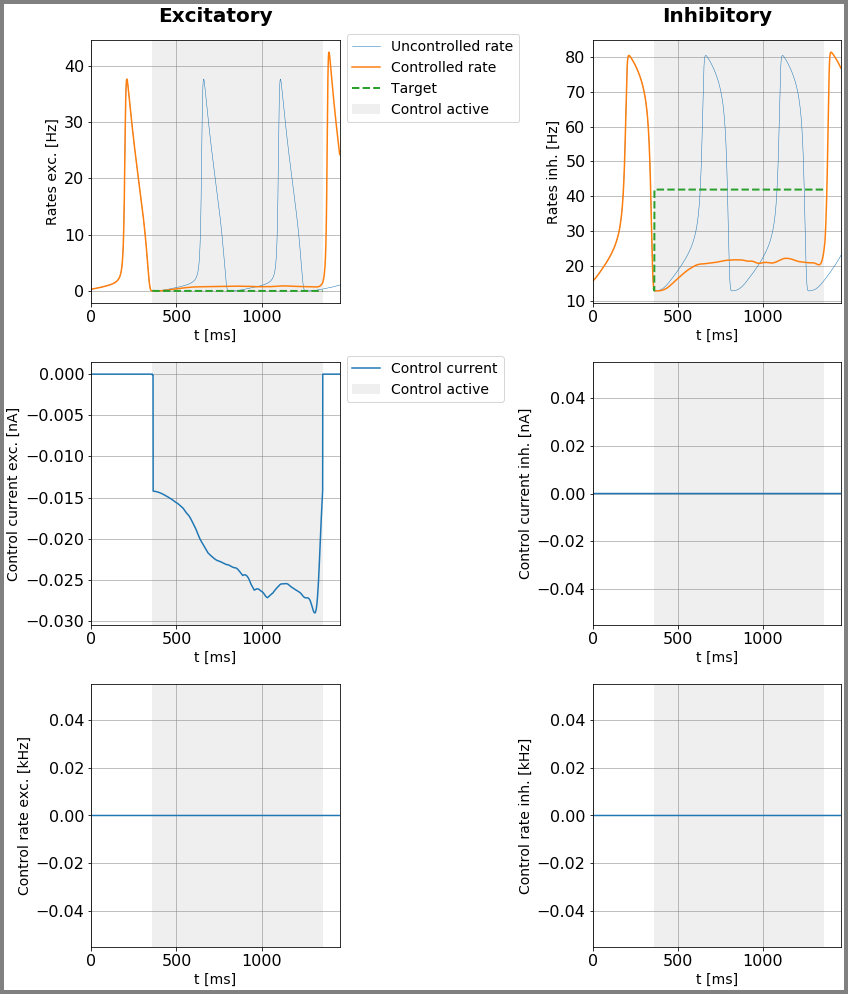

In [13]:

# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 3.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,0,n_dt_maxDelay:] = -5.
#control2 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )


## 2

set cost params
control input:  [2] , precision measure:  [0]
RUN  0 , total integrated cost =  62300.14237865519
RUN  1 , total integrated cost =  62300.14237865514
RUN  2 , total integrated cost =  62300.14237865513


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  62300.14237865513
Control only changes marginally.
RUN  3 , total integrated cost =  62300.14237865513
Improved over  3  iterations by  8.526512829121202e-14  percent.
Problem in initial value trasfer:  sigmae_f 1.5491497473728457 1.547962157653109
Problem in initial value trasfer:  Vmean_exc -66.44625475776829 -66.46091118730271
Problem in initial value trasfer:  tau_exc 19.998815651646705 20.008943210951703
Problem in initial value trasfer:  sigmae_f 1.5073996341688258 1.5082466467837208
Problem in initial value trasfer:  Vmean_exc -56.76635366298343 -56.76880927892181
Problem in initial value trasfer:  tau_exc 4.86230082396733 4.8606442597106465


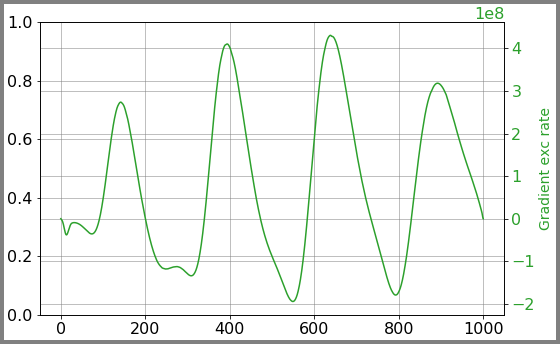

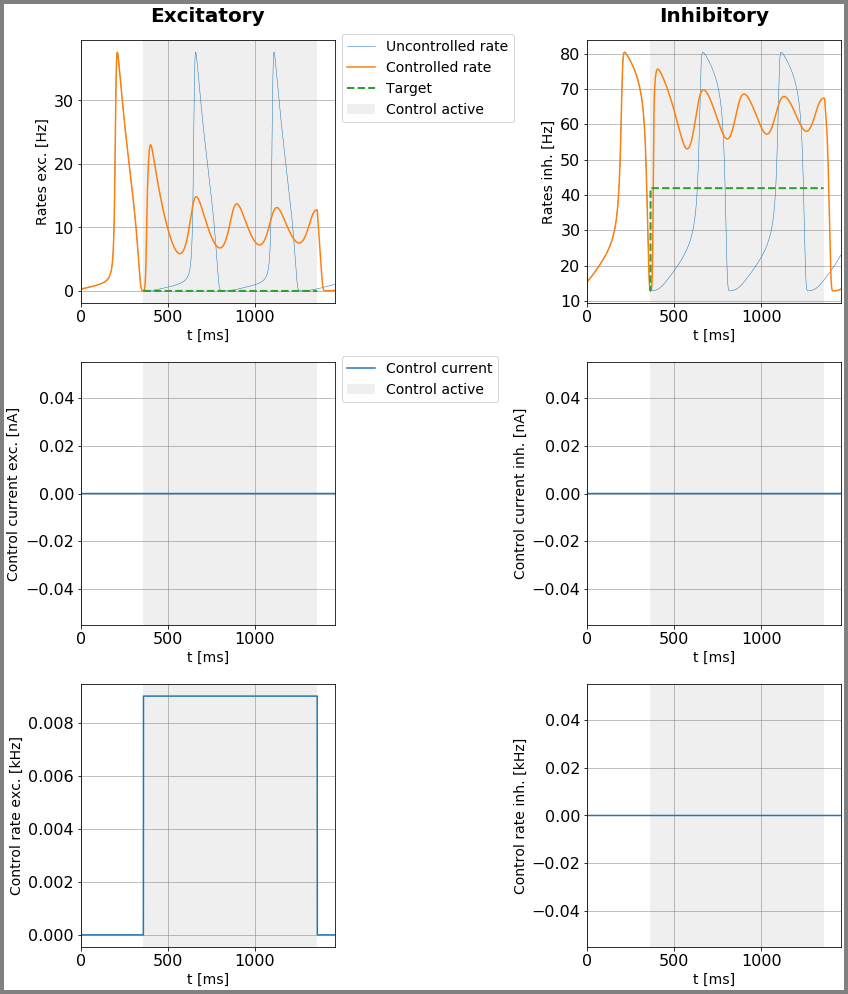

In [16]:
# A.0.a)

case_ind = 2
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

dur_pre, n_pre = setpredur(prec_vars)

target = settarget(initVars, dur, dur_pre, n_pre)

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,2,:] = 0.009
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl,  t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.)


plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

set cost params
RUN  0 , total integrated cost =  62302.21135781305


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  62302.21135781305
Control only changes marginally.
RUN  1 , total integrated cost =  62302.21135781305
Improved over  1  iterations by  0.0  percent.
Problem in initial value trasfer:  sigmae_f 1.5491497473728457 1.547962157653109
Problem in initial value trasfer:  Vmean_exc -66.44625475776829 -66.46091118730271
Problem in initial value trasfer:  tau_exc 19.998815651646705 20.008943210951703
Problem in initial value trasfer:  sigmae_f 1.5073996341688258 1.5082466467837208
Problem in initial value trasfer:  Vmean_exc -56.76635366298343 -56.76880927892181
Problem in initial value trasfer:  tau_exc 4.86230082396733 4.8606442597106465


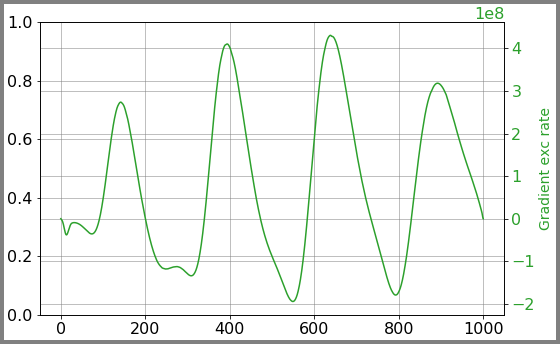

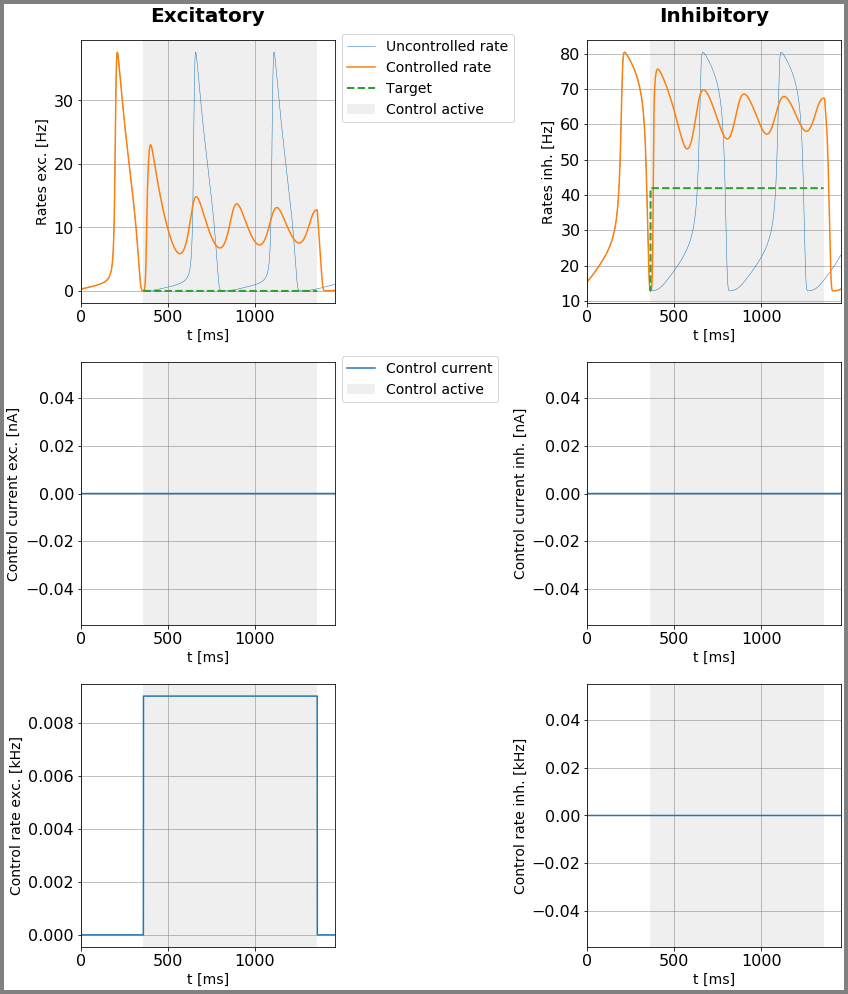

In [17]:

# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 3.0)

aln.params.duration = dur

setinit(initVars)
ontrol0 = aln.getZeroControl()
#control0[0,2,:] = 0.
control1 = bestControla[:,:,n_pre-1:-n_post+1]
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control1, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

## 4

set cost params
control input:  [1] , precision measure:  [0]
RUN  0 , total integrated cost =  0.008065989836125925


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  0.008065989836125925
Control only changes marginally.
RUN  1 , total integrated cost =  0.008065989836125925
Improved over  1  iterations by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -66.44625475776829 -66.4609634346849
Problem in initial value trasfer:  Vmean_exc -67.25821055826606 -67.25821046416624


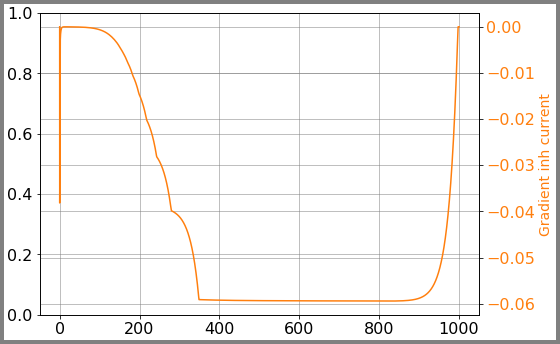

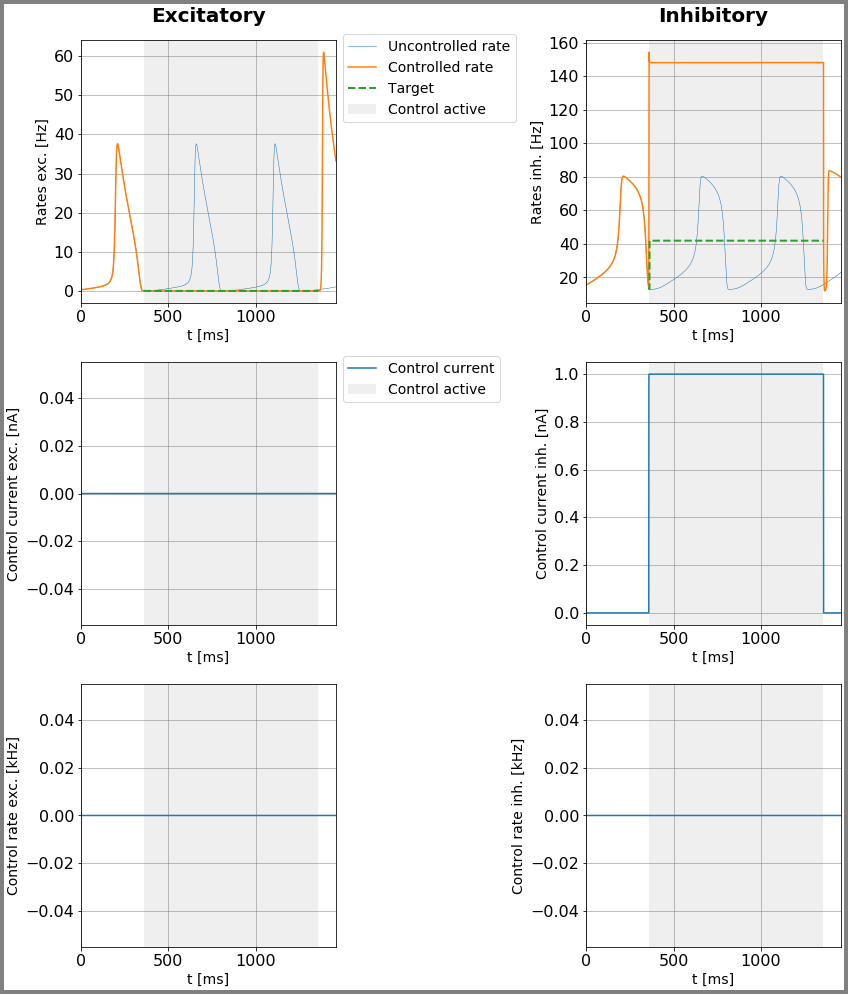

In [20]:
# A.4.a)

case_ind = 4
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

dur_pre, n_pre = setpredur(prec_vars)

target = settarget(initVars, dur, dur_pre, n_pre)

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,1,:] = 5.
#control1 = bestControla[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.)


plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

set cost params
RUN  0 , total integrated cost =  375511.87343150465
RUN  1 , total integrated cost =  4117.016039766341


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  2 , total integrated cost =  4117.016039766341
Control only changes marginally.
RUN  2 , total integrated cost =  4117.016039766341
Improved over  2  iterations by  98.9036256025291  percent.
Problem in initial value trasfer:  Vmean_exc -66.44625475776829 -66.4609634346849
Problem in initial value trasfer:  Vmean_exc -62.94733154537182 -62.94728371248904


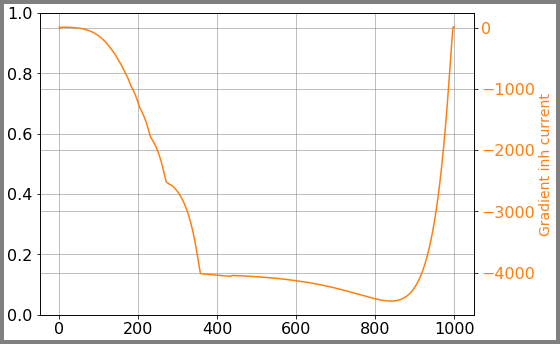

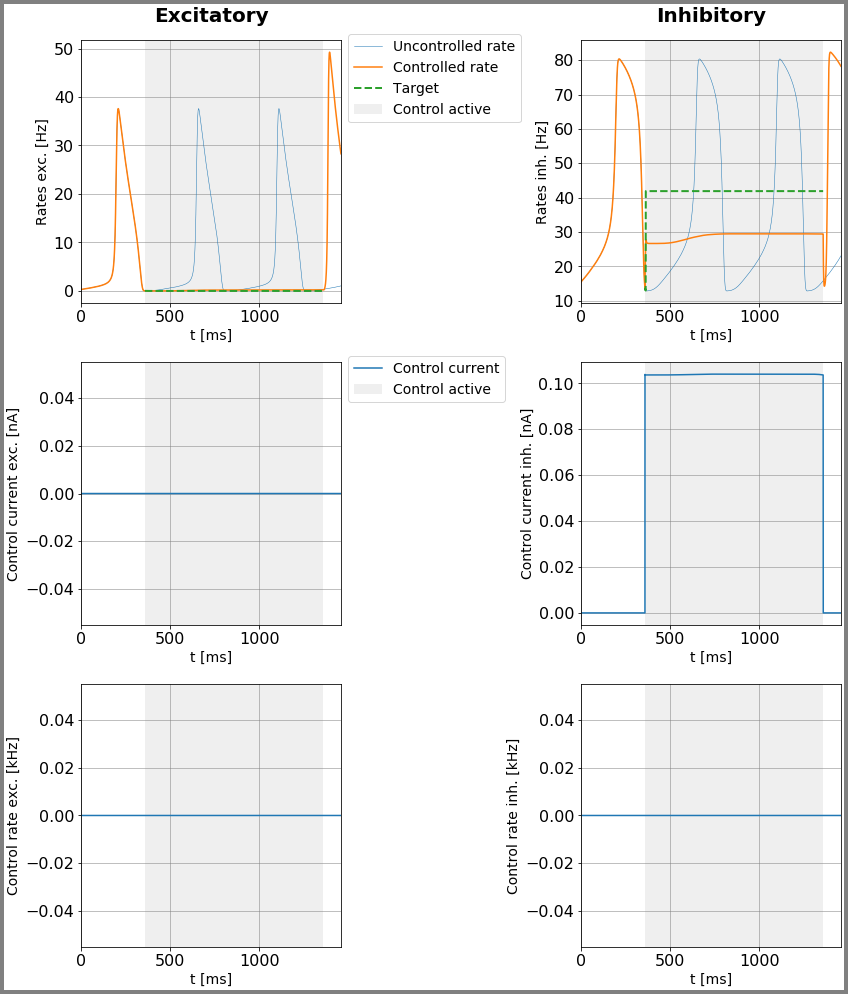

In [21]:
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 3.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,1,:] = 5.
#control2 = bestControlb[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

## 6

set cost params
control input:  [0, 1] , precision measure:  [0]
RUN  0 , total integrated cost =  0.0003877654148433748
RUN  1 , total integrated cost =  0.00033332728100802573
RUN  2 , total integrated cost =  0.0003328748849667128
RUN  3 , total integrated cost =  0.00033287439860297705
RUN  4 , total integrated cost =  0.0003328743985339874
RUN  5 , total integrated cost =  0.00033287439853398715
RUN  6 , total integrated cost =  0.0003328743985339871
RUN  7 , total integrated cost =  0.000332874398533987


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  8 , total integrated cost =  0.000332874398533987
Control only changes marginally.
RUN  8 , total integrated cost =  0.000332874398533987
Improved over  8  iterations by  14.15572771789337  percent.
Problem in initial value trasfer:  Vmean_exc -66.44625475776829 -66.4609634346849
Problem in initial value trasfer:  Vmean_exc -82.00315669350884 -82.00315524899855


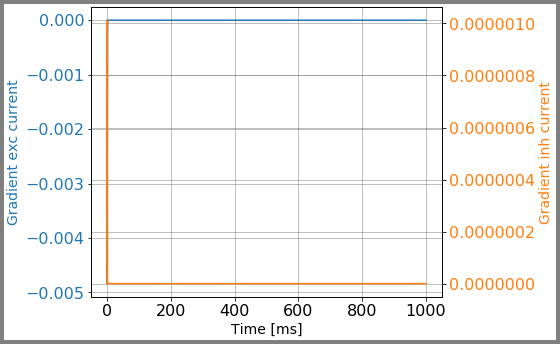

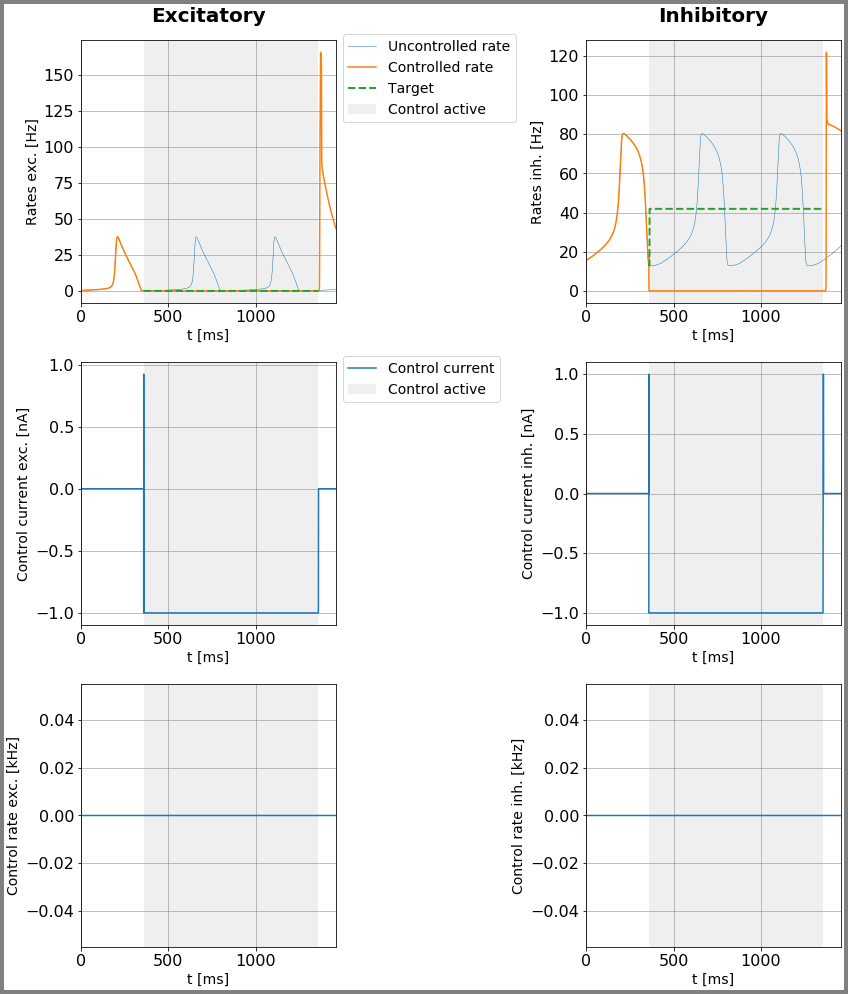

In [24]:
# A.6.a)
case_ind = 6
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

dur_pre, n_pre = setpredur(prec_vars)

target = settarget(initVars, dur, dur_pre, n_pre)

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,0,:] = -5.
control0[0,1,:] = 5.
#control1 = bestControla[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)


bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.)


plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

set cost params
RUN  0 , total integrated cost =  751023.7311187951
RUN  1 , total integrated cost =  434.89459946995663
RUN  2 , total integrated cost =  412.66777448774377
RUN  3 , total integrated cost =  411.4078858616184
RUN  4 , total integrated cost =  411.4078858616179


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  411.4078858616179
Control only changes marginally.
RUN  5 , total integrated cost =  411.4078858616179
Improved over  5  iterations by  99.94522038800974  percent.
Problem in initial value trasfer:  Vmean_exc -66.44625475776829 -66.4609634346849
Problem in initial value trasfer:  Vmean_exc -60.425110809914045 -60.4218444954473


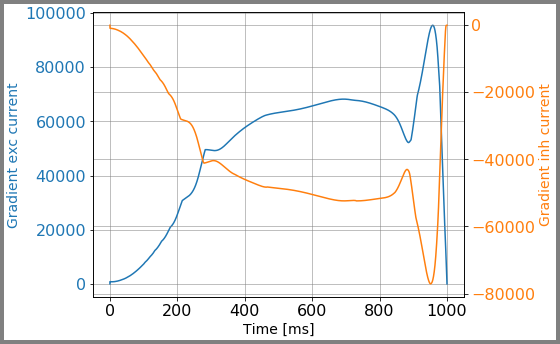

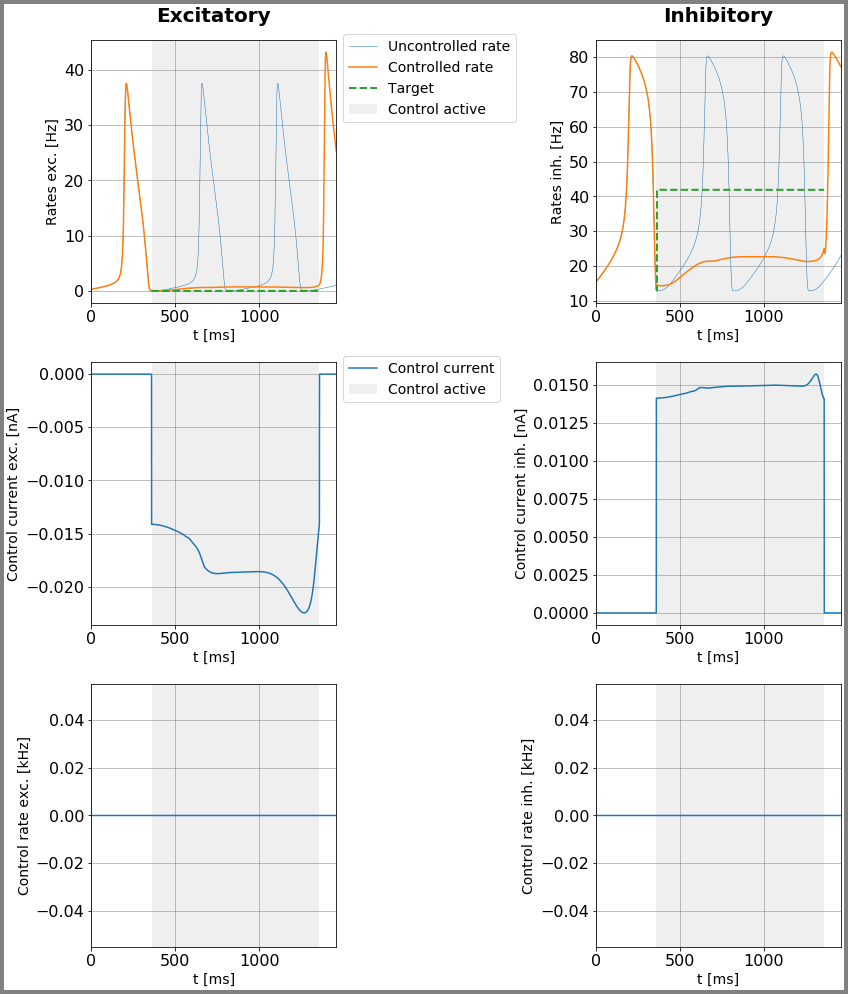

In [25]:
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 3.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,0,:] = -5.
control0[0,1,:] = 5.
#control2 = bestControlb[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

## 8

set cost params
control input:  [0, 2] , precision measure:  [0]
RUN  0 , total integrated cost =  0.00038776488676224775
RUN  1 , total integrated cost =  0.0002928213282779221
RUN  2 , total integrated cost =  0.00028754063950307113
RUN  3 , total integrated cost =  0.00028753059229238504
RUN  4 , total integrated cost =  0.0002875305620596748
RUN  5 , total integrated cost =  0.00028753056199613114
RUN  6 , total integrated cost =  0.00028753056199611965
RUN  7 , total integrated cost =  0.0002875305619961195
RUN  8 , total integrated cost =  0.0002875305619961193
RUN  9 , total integrated cost =  0.00028753056199611905


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  10 , total integrated cost =  0.00028753056199611905
Control only changes marginally.
RUN  10 , total integrated cost =  0.00028753056199611905
Improved over  10  iterations by  25.84925252078996  percent.
Problem in initial value trasfer:  sigmae_f 1.5491497473728457 1.545974069152225
Problem in initial value trasfer:  Vmean_exc -66.44625475776829 -66.4608237224017
Problem in initial value trasfer:  tau_exc 19.998815651646705 20.02589728512536


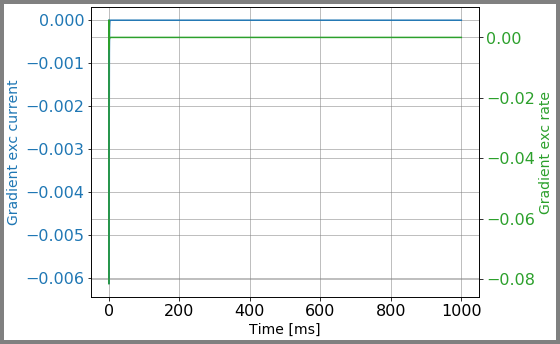

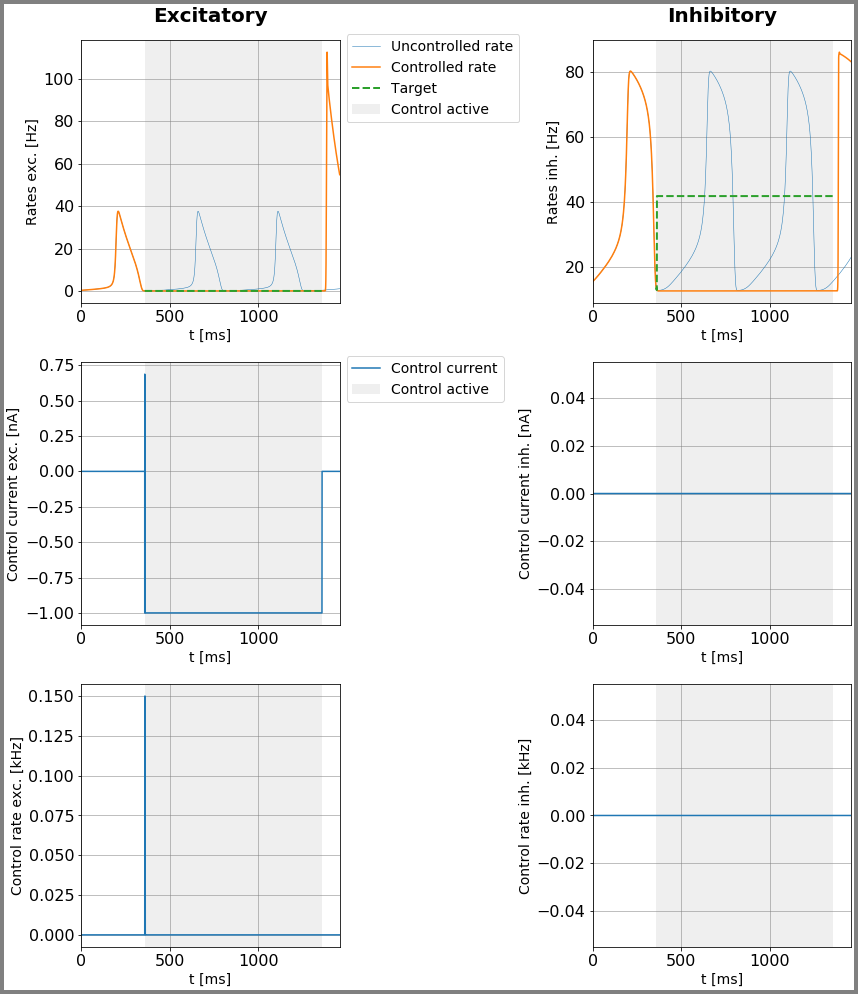

In [28]:
# A.8.a)
case_ind = 8
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

dur_pre, n_pre = setpredur(prec_vars)

target = settarget(initVars, dur, dur_pre, n_pre)

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,0,:] = -5.
#control1 = bestControla[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.)


plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

set cost params
RUN  0 , total integrated cost =  375511.8657532797
RUN  1 , total integrated cost =  581.3155413830409
RUN  2 , total integrated cost =  549.8807721262373
RUN  3 , total integrated cost =  548.2016938676148
RUN  4 , total integrated cost =  545.4924086800274
RUN  5 , total integrated cost =  540.7509962818376
RUN  6 , total integrated cost =  534.4030855879107
RUN  7 , total integrated cost =  521.7963847459351
RUN  8 , total integrated cost =  513.8068940015481
RUN  9 , total integrated cost =  503.2038740323394
RUN  10 , total integrated cost =  492.55705290714195
RUN  11 , total integrated cost =  479.8882738914781
RUN  12 , total integrated cost =  472.79858698680175
RUN  13 , total integrated cost =  471.31810803655856
RUN  14 , total integrated cost =  471.31307459804776
RUN  15 , total integrated cost =  471.313066333603
RUN  16 , total integrated cost =  471.31306633355035
RUN  17 , total integrated cost =  471.31306633354694
RUN  18 , total integrated cost =  

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  23 , total integrated cost =  471.3130663335371
Improved over  23  iterations by  99.87448783665249  percent.
Problem in initial value trasfer:  sigmae_f 1.5491497473728457 1.5477932740004319
Problem in initial value trasfer:  Vmean_exc -66.44625475776829 -66.46090375736115
Problem in initial value trasfer:  tau_exc 19.998815651646705 20.01038342147198
Problem in initial value trasfer:  Vmean_exc -59.99687049049942 -59.99004918369819


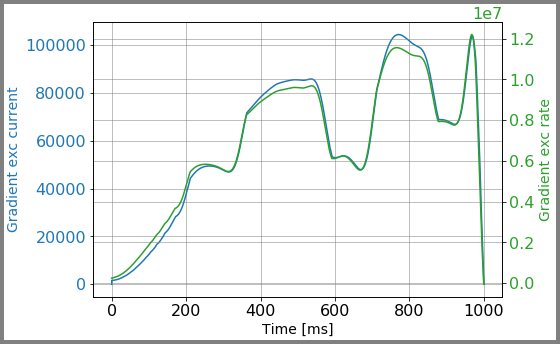

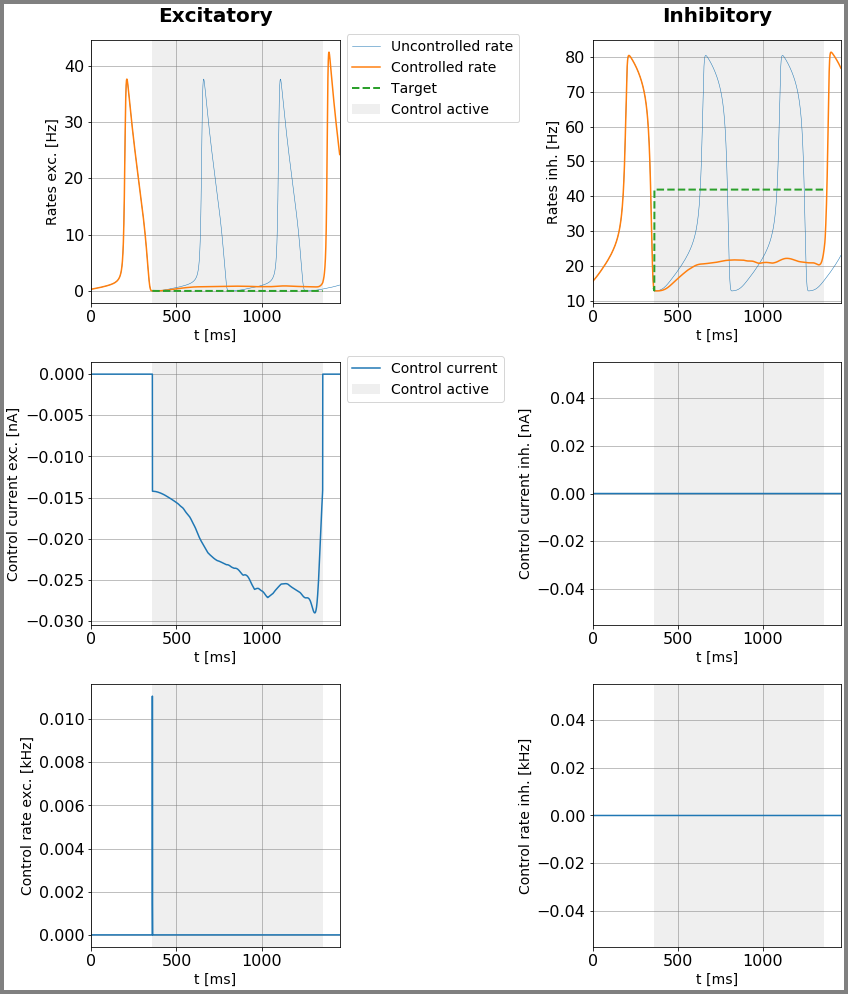

In [29]:
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 3.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,0,:] = -5.
#control2 = bestControlb[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

## 10

set cost params
control input:  [1, 2] , precision measure:  [0]
RUN  0 , total integrated cost =  0.008065989836125925
RUN  1 , total integrated cost =  0.008065974924694136


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  2 , total integrated cost =  0.008065974924694136
Control only changes marginally.
RUN  2 , total integrated cost =  0.008065974924694136
Improved over  2  iterations by  0.00018486797146977096  percent.
Problem in initial value trasfer:  Vmean_exc -66.44625475776829 -66.4609634346849
Problem in initial value trasfer:  Vmean_exc -67.25820191499847 -67.29250322699123


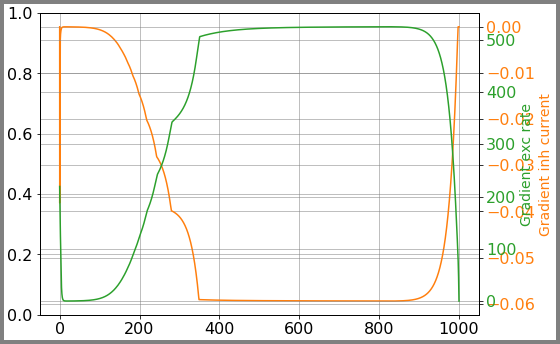

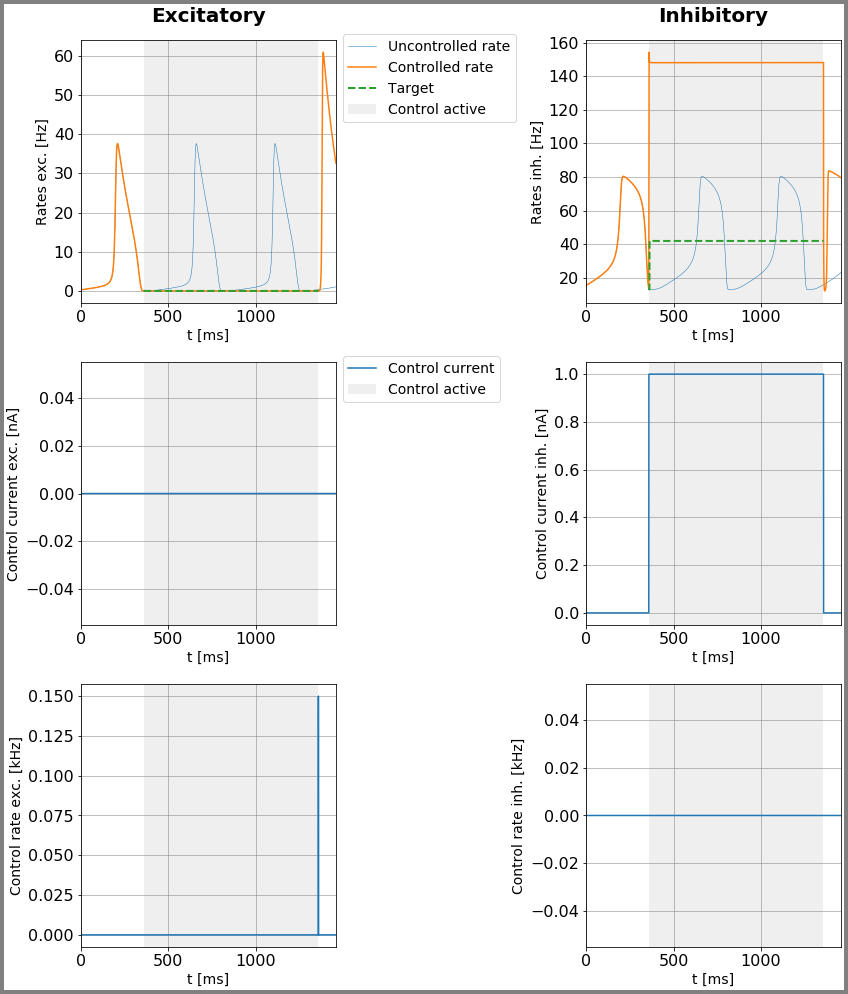

In [32]:
# A.10.a)
case_ind = 10
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

dur_pre, n_pre = setpredur(prec_vars)

target = settarget(initVars, dur, dur_pre, n_pre)

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,1,:] = 5.
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.)


plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

set cost params
RUN  0 , total integrated cost =  375511.87343150465
RUN  1 , total integrated cost =  4117.016039766341


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  2 , total integrated cost =  4117.016039766341
Control only changes marginally.
RUN  2 , total integrated cost =  4117.016039766341
Improved over  2  iterations by  98.9036256025291  percent.
Problem in initial value trasfer:  Vmean_exc -66.44625475776829 -66.4609634346849
Problem in initial value trasfer:  Vmean_exc -62.94733154537182 -62.94728371248904


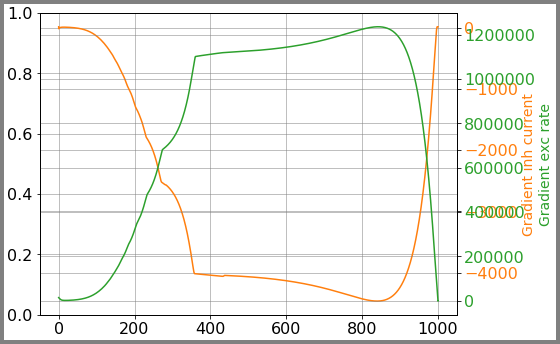

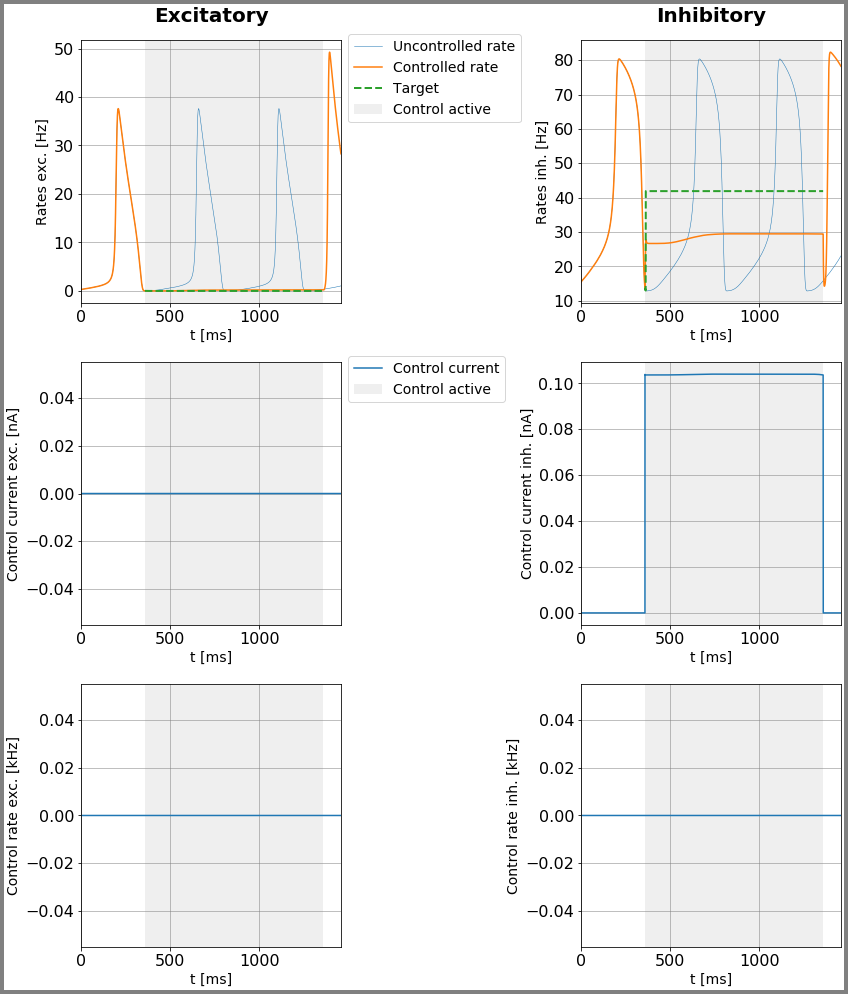

In [33]:
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 3.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,1,:] = 5.
#control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

## 12

set cost params
control input:  [0, 1, 2] , precision measure:  [0]
RUN  0 , total integrated cost =  0.0003877654148433748
RUN  1 , total integrated cost =  0.0002934042242694672
RUN  2 , total integrated cost =  0.00028745232432883224
RUN  3 , total integrated cost =  0.00028713652866226166
RUN  4 , total integrated cost =  0.00028713361772624593
RUN  5 , total integrated cost =  0.00028713356552502125
RUN  6 , total integrated cost =  0.0002871335654821975
RUN  7 , total integrated cost =  0.00028713356548218047
RUN  8 , total integrated cost =  0.0002871335654821452
RUN  9 , total integrated cost =  0.00028713356548214496
RUN  10 , total integrated cost =  0.00028713356548214474


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  11 , total integrated cost =  0.00028713356548214474
Control only changes marginally.
RUN  11 , total integrated cost =  0.00028713356548214474
Improved over  11  iterations by  25.951734092086838  percent.
Problem in initial value trasfer:  sigmae_f 1.5491497473728457 1.545974069152225
Problem in initial value trasfer:  Vmean_exc -66.44625475776829 -66.4608237224017
Problem in initial value trasfer:  tau_exc 19.998815651646705 20.02589728512536
Problem in initial value trasfer:  Vmean_exc -81.9985739840929 -81.99858857257695


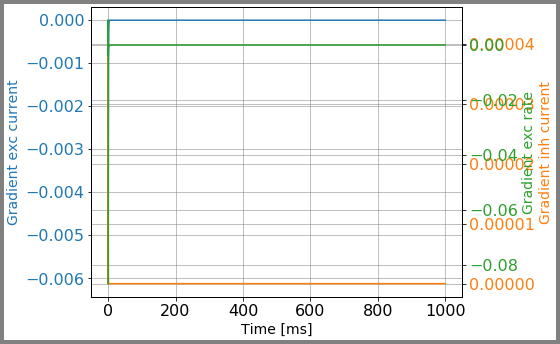

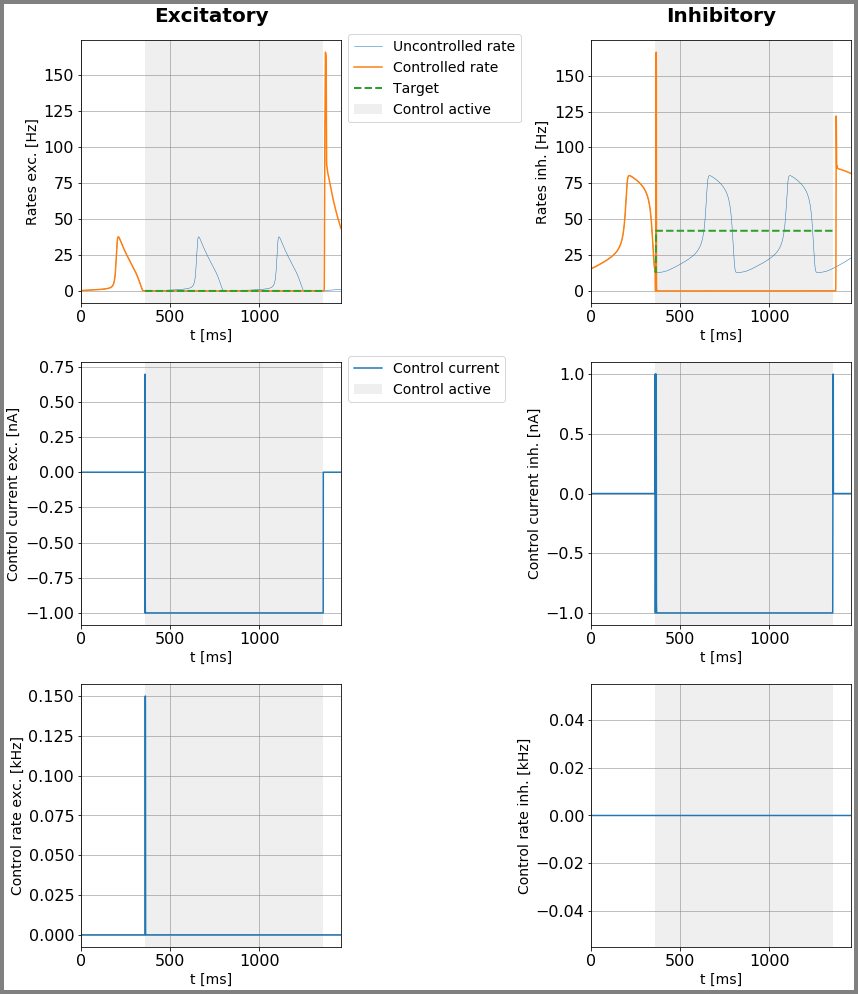

In [36]:
# A.12.a)
case_ind = 12
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

dur_pre, n_pre = setpredur(prec_vars)

target = settarget(initVars, dur, dur_pre, n_pre)

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,0,:] = -5.
control0[0,1,:] = 5.
#control1 = bestControla[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.)


plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

set cost params
RUN  0 , total integrated cost =  751023.7311187951
RUN  1 , total integrated cost =  434.69886613038005
RUN  2 , total integrated cost =  412.48697501628635
RUN  3 , total integrated cost =  411.4069095681023
RUN  4 , total integrated cost =  411.40688250553706
RUN  5 , total integrated cost =  411.4068825055368
RUN  6 , total integrated cost =  411.4068825055367
RUN  7 , total integrated cost =  411.4068825055366


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  8 , total integrated cost =  411.4068825055366
Control only changes marginally.
RUN  8 , total integrated cost =  411.4068825055366
Improved over  8  iterations by  99.94522052160819  percent.
Problem in initial value trasfer:  sigmae_f 1.5491497473728457 1.5487655870742705
Problem in initial value trasfer:  Vmean_exc -66.44625475776829 -66.46094653375937
Problem in initial value trasfer:  tau_exc 19.998815651646705 20.002091704092923
Problem in initial value trasfer:  Vmean_exc -60.4219162512221 -60.42970372885456


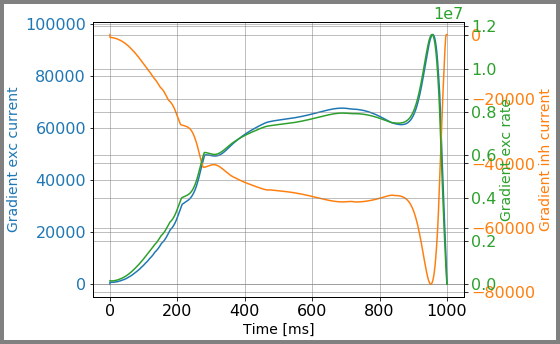

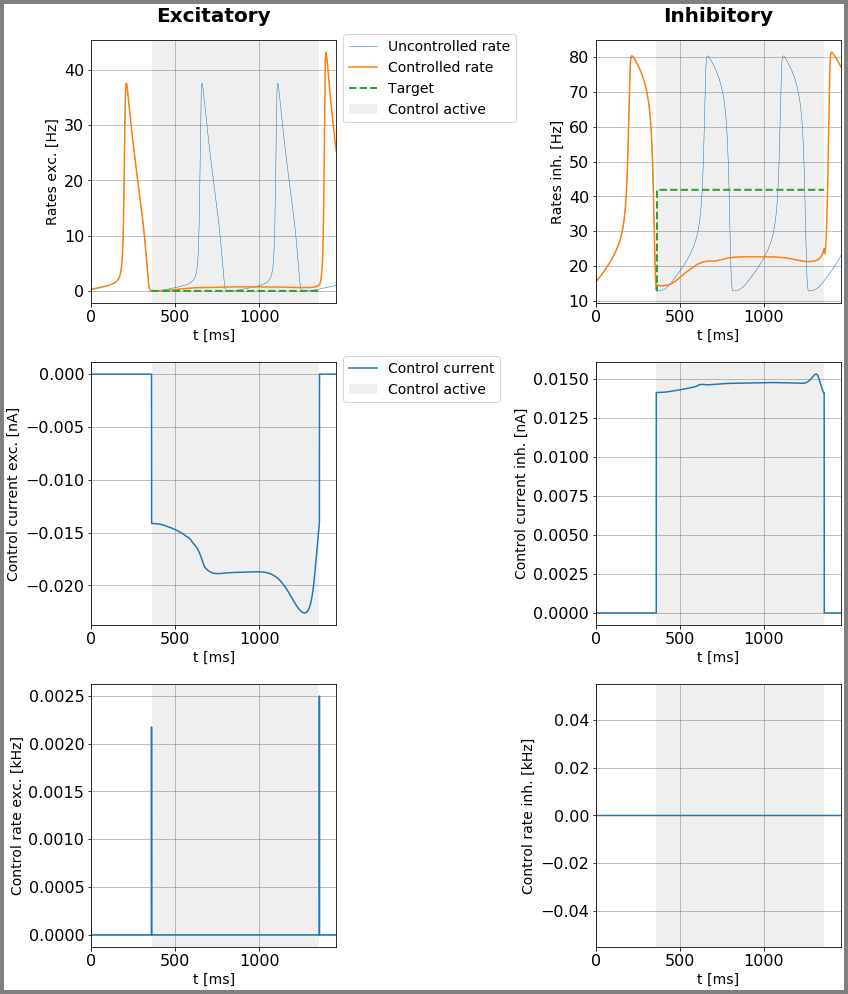

In [37]:
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 3.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,0,:] = -5.
control0[0,1,:] = 5.
#control2 = bestControlb[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )